In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
  
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Yeo-Johnson Transform for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical using the min max scaling
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

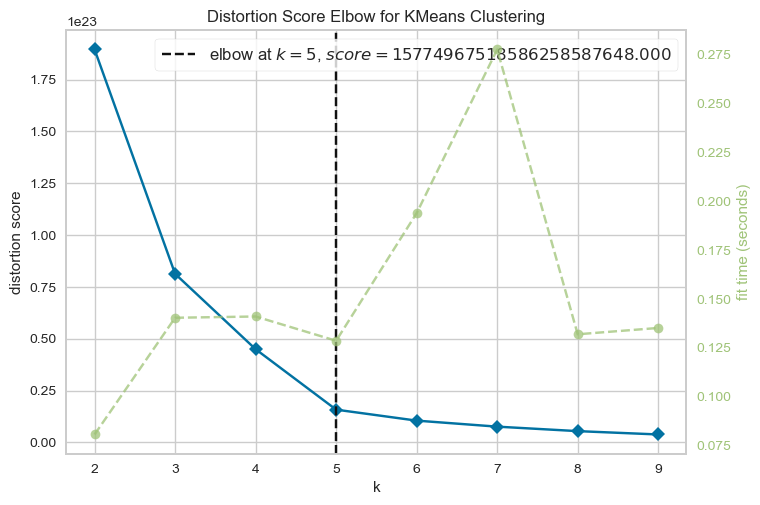

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: first_order_InterquartileRange_PET, Coefficient: 2.7991469187193396


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: first_order_90Percentile_CT, Coefficient: -232577890478451.7


...

Cluster 2: Most important feature: glcm_DifferenceAverage_d_1_PET_c04, Coefficient: 3.0814993361726515


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: gldm_DependenceNonUniformity_d_1_CT_c16, Coefficient: -4.859902321389764


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: glcm_SumEntropy_d_1_CT_b20, Coefficient: -1.916899505812213


In [21]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Yeo-Johnson Transformation

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = pt.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,first_order_InterquartileRange_PET,first_order_90Percentile_CT,glcm_DifferenceAverage_d_1_PET_c04,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_SumEntropy_d_1_CT_b20
0,6.511572,1177.917830,0.356587,795.553102,4.502601
1,2.327072,1109.046098,0.420129,123.426126,4.029619
2,2.906756,1149.884925,0.325835,4018.147125,3.897194
3,1.000875,1126.003305,0.401664,132.029667,4.404209
4,2.265340,1134.384047,0.510112,198.074133,4.260762
...,...,...,...,...,...
134,3.794042,1157.360037,0.409956,364.958418,3.731694
135,2.317546,1126.367132,0.321183,7880.282053,3.187893
136,5.523401,1111.612526,0.374487,2004.754079,3.389761
137,2.923708,1117.834717,0.402135,1231.652900,2.657632


In [25]:
X_new_std

,first_order_InterquartileRange_PET,first_order_90Percentile_CT,glcm_DifferenceAverage_d_1_PET_c04,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_SumEntropy_d_1_CT_b20
0,0.950967,8.604228e-16,-0.094031,-0.281322,1.342477
1,-0.725408,-3.885781e-16,0.595643,-1.538990,0.669418
2,-0.403538,3.885781e-16,-0.468257,0.720827,0.472781
3,-1.717069,-5.551115e-17,0.405940,-1.491572,1.206024
4,-0.762667,1.110223e-16,1.412495,-1.209134,1.003821
...,...,...,...,...,...
134,0.012774,5.273559e-16,0.492151,-0.793546,0.221532
135,-0.731116,-5.551115e-17,-0.527421,1.113717,-0.651772
136,0.652577,-3.330669e-16,0.111075,0.300721,-0.318483
137,-0.394802,-2.220446e-16,0.410886,-0.002663,-1.586571


In [26]:
MAASTRO_new

,first_order_InterquartileRange_PET,first_order_90Percentile_CT,glcm_DifferenceAverage_d_1_PET_c04,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_SumEntropy_d_1_CT_b20
0,6.977681,1103.940398,0.335443,12196.315125,2.689462
1,2.552737,1117.575395,0.279434,4519.652975,3.565088
2,5.524582,1110.775817,0.310763,3625.016252,3.167379
3,2.858052,1191.267456,0.301684,635.235614,5.165432
4,3.442758,1108.918120,0.300615,3431.608089,2.889834
...,...,...,...,...,...
94,17.543654,1132.303273,0.327473,2609.957482,3.981885
95,5.097148,1108.789902,0.310449,2051.596318,4.553938
96,2.527841,1107.996338,0.264803,3489.732357,3.291814
97,5.667688,1161.546578,0.305581,3253.768315,4.214845


In [27]:
MAASTRO_new_std

,first_order_InterquartileRange_PET,first_order_90Percentile_CT,glcm_DifferenceAverage_d_1_PET_c04,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_SumEntropy_d_1_CT_b20
0,1.079376,-5.273559e-16,-0.348239,1.361299,-1.527777
1,-0.594404,-2.220446e-16,-1.090997,0.790419,-0.037920
2,0.652958,-3.608225e-16,-0.662484,0.659558,-0.686288
3,-0.428830,1.082467e-15,-0.783134,-0.427211,2.218374
4,-0.142831,-3.885781e-16,-0.797524,0.626799,-1.165875
...,...,...,...,...,...
94,2.946421,8.326673e-17,-0.447593,0.461885,0.598976
95,0.510834,-4.163336e-16,-0.666615,0.314918,1.412971
96,-0.608476,-4.163336e-16,-1.303381,0.636844,-0.478775
97,0.698634,6.106227e-16,-0.731004,0.594915,0.938252


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 03:19:24,175] A new study created in memory with name: no-name-d4724469-0d19-4cdd-85df-8d9d641b260b
python(7351) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.6176470588235294
Fold 4 C-index: 0.6497890295358649


[I 2024-04-18 03:19:25,032] A new study created in memory with name: no-name-1b7ebf96-241c-4437-bfd4-d1e5cf482bd4


Fold 5 C-index: 0.596244131455399
[I 2024-04-18 03:19:25,021] Trial 0 finished with value: 0.6386721911491059 and parameters: {}. Best is trial 0 with value: 0.6386721911491059.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6386721911491059], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 24, 403580), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 25, 20592), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6386721911491059


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.211511402355164
Fold 2 IBS: 0.1914836199587804
Fold 3 IBS: 0.18774020112330322
Fold 4 IBS: 0.19935152334431425
Fold 5 IBS: 0.22222717736913997
[I 2024-04-18 03:19:25,642] Trial 0 finished with value: 0.20246278483014035 and parameters: {}. Best is trial 0 with value: 0.20246278483014035.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20246278483014035], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 25, 114793), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 25, 641699), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20246278483014035


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.639
train_ibs:  0.202


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.605
IBS score: 0.221


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:19:26,054] A new study created in memory with name: no-name-d180e268-76d5-496d-9783-ca036d8f42c8


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-18 03:19:26,438] A new study created in memory with name: no-name-18cd1614-924d-42d6-a16c-499a5b938881


Fold 1 C-index: 0.6255411255411255
Fold 2 C-index: 0.8236607142857143
Fold 3 C-index: 0.6004901960784313
Fold 4 C-index: 0.6476793248945147
Fold 5 C-index: 0.5821596244131455
[I 2024-04-18 03:19:26,428] Trial 0 finished with value: 0.6559061970425863 and parameters: {}. Best is trial 0 with value: 0.6559061970425863.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6559061970425863], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 26, 145226), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 26, 428106), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6559061970425863


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765168934727
Fold 2 IBS: 0.2215779053678894
Fold 3 IBS: 0.20453594147399054
Fold 4 IBS: 0.2247380347948306
Fold 5 IBS: 0.21812431267707938
[I 2024-04-18 03:19:26,797] Trial 0 finished with value: 0.21659054224145252 and parameters: {}. Best is trial 0 with value: 0.21659054224145252.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054224145252], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 26, 484803), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 26, 797541), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054224145252


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.656
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.572


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:19:27,325] A new study created in memory with name: no-name-bb306c64-04be-41b7-9faf-2cadafc3e1e0


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6176470588235294


[I 2024-04-18 03:19:28,313] A new study created in memory with name: no-name-1030de8a-795d-4abd-a0c9-6339555cb912


Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5868544600938967
[I 2024-04-18 03:19:28,296] Trial 0 finished with value: 0.6445683129894691 and parameters: {}. Best is trial 0 with value: 0.6445683129894691.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6445683129894691], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 27, 389255), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 28, 296271), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6445683129894691


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.20741419743544454
Fold 2 IBS: 0.18850052721769286
Fold 3 IBS: 0.1874524856987202
Fold 4 IBS: 0.19106725219617196
Fold 5 IBS: 0.2264138811818621
[I 2024-04-18 03:19:28,936] Trial 0 finished with value: 0.20016966874597833 and parameters: {}. Best is trial 0 with value: 0.20016966874597833.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20016966874597833], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 28, 374028), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 28, 936450), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20016966874597833


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.645
train_ibs:  0.2


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.608


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.216


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:19:29,375] A new study created in memory with name: no-name-1d9eed07-6020-4a52-9651-5ccfdfc19d9d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5868544600938967
[I 2024-04-18 03:19:29,928] Trial 0 finished with value: 0.6455487051463319 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6455487051463319.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5868544600938967
[I 2024-04-18 03:19:30,440] Trial 1 finished with value: 0.6455487051463319 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6455487051463319.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 03:19:30,988] Trial 2 finished with value: 0.646487672282482 and parameters: {'l1_ratio': 0.22692876841884668}. Bes

Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5868544600938967
[I 2024-04-18 03:19:40,700] Trial 24 finished with value: 0.6455487051463319 and parameters: {'l1_ratio': 0.31612098478358897}. Best is trial 12 with value: 0.6616843953905976.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 03:19:41,250] Trial 25 finished with value: 0.646487672282482 and parameters: {'l1_ratio': 0.08890608406899088}. Best is trial 12 with value: 0.6616843953905976.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 03:19:41,799] Trial 26 finished with value: 0.646487672282482 and parameters: {'l1_ratio': 0.23521758130887002}. Best is trial 12 with value: 0.66

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 03:20:01,399] Trial 48 finished with value: 0.646487672282482 and parameters: {'l1_ratio': 0.11665469251074127}. Best is trial 12 with value: 0.6616843953905976.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.8125
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 03:20:02,055] Trial 49 finished with value: 0.6512947850009873 and parameters: {'l1_ratio': 0.03759548139778833}. Best is trial 12 with value: 0.6616843953905976.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 03:20:02,700] Trial 50 finished with value: 0.646487672282482 and parameters: {'l1_ratio': 0.08888770157152942}. Best is t

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.20744566248748766
Fold 2 IBS: 0.1885022042646457
Fold 3 IBS: 0.1874563354223859
Fold 4 IBS: 0.19106734082296425
Fold 5 IBS: 0.22641105617669813
[I 2024-04-18 03:21:16,111] Trial 0 finished with value: 0.20017651983483634 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.20017651983483634.
Fold 1 IBS: 0.2075481779676616
Fold 2 IBS: 0.1885056453685496
Fold 3 IBS: 0.18740716076345254
Fold 4 IBS: 0.19105510046970983
Fold 5 IBS: 0.22647300657345454
[I 2024-04-18 03:21:17,592] Trial 1 finished with value: 0.2001978182285656 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.20017651983483634.
Fold 1 IBS: 0.2075980819774742
Fold 2 IBS: 0.1885082740227597
Fold 3 IBS: 0.18741180835749816
Fold 4 IBS: 0.1910184642005845
Fold 5 IBS: 0.22645325427778792
[I 2024-04-18 03:21:18,737] Trial 2 finished with value: 0.2001979765672209 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.20017651983483634.

Fold 1 IBS: 0.20748928277630518
Fold 2 IBS: 0.18849965910739372
Fold 3 IBS: 0.18744517662796975
Fold 4 IBS: 0.19102649910686287
Fold 5 IBS: 0.22645323083165142
[I 2024-04-18 03:21:58,827] Trial 25 finished with value: 0.2001827696900366 and parameters: {'l1_ratio': 0.6427594368859761}. Best is trial 21 with value: 0.2001559241393936.
Fold 1 IBS: 0.20746171017034995
Fold 2 IBS: 0.18849796881360478
Fold 3 IBS: 0.18746656561496425
Fold 4 IBS: 0.19102386287941384
Fold 5 IBS: 0.22640017442268093
[I 2024-04-18 03:22:01,009] Trial 26 finished with value: 0.20017005638020277 and parameters: {'l1_ratio': 0.9167426588025347}. Best is trial 21 with value: 0.2001559241393936.
Fold 1 IBS: 0.21320303448786296
Fold 2 IBS: 0.2198297474037231
Fold 3 IBS: 0.20364580284367767
Fold 4 IBS: 0.22372531478960925
Fold 5 IBS: 0.21774176509146514
[I 2024-04-18 03:22:02,268] Trial 27 finished with value: 0.21562913292326763 and parameters: {'l1_ratio': 0.016560941611969082}. Best is trial 21 with value: 0.2001559

Fold 1 IBS: 0.20747890683815848
Fold 2 IBS: 0.18850234361427526
Fold 3 IBS: 0.18744866442474292
Fold 4 IBS: 0.19105425622213212
Fold 5 IBS: 0.2264229764120601
[I 2024-04-18 03:22:48,831] Trial 50 finished with value: 0.20018142950227377 and parameters: {'l1_ratio': 0.556147470734502}. Best is trial 21 with value: 0.2001559241393936.
Fold 1 IBS: 0.20741238645380877
Fold 2 IBS: 0.188497310095864
Fold 3 IBS: 0.1874484016922644
Fold 4 IBS: 0.19107222940651647
Fold 5 IBS: 0.2264084524696034
[I 2024-04-18 03:22:50,205] Trial 51 finished with value: 0.20016775602361142 and parameters: {'l1_ratio': 0.9652982010146854}. Best is trial 21 with value: 0.2001559241393936.
Fold 1 IBS: 0.20741207591163724
Fold 2 IBS: 0.18849738391636545
Fold 3 IBS: 0.18744770257112467
Fold 4 IBS: 0.19101770787170771
Fold 5 IBS: 0.22640752172334608
[I 2024-04-18 03:22:51,806] Trial 52 finished with value: 0.20015647839883624 and parameters: {'l1_ratio': 0.9595865292004943}. Best is trial 21 with value: 0.2001559241393

Fold 1 IBS: 0.20745885839298725
Fold 2 IBS: 0.18849870825134796
Fold 3 IBS: 0.18746021326304782
Fold 4 IBS: 0.1910315899686349
Fold 5 IBS: 0.22645004296388851
[I 2024-04-18 03:23:38,281] Trial 75 finished with value: 0.2001798825679813 and parameters: {'l1_ratio': 0.8680508807663194}. Best is trial 21 with value: 0.2001559241393936.
Fold 1 IBS: 0.2074607572698309
Fold 2 IBS: 0.1884982152581527
Fold 3 IBS: 0.18746443984259872
Fold 4 IBS: 0.1910264448808601
Fold 5 IBS: 0.2264556585201368
[I 2024-04-18 03:23:40,021] Trial 76 finished with value: 0.20018110315431584 and parameters: {'l1_ratio': 0.899880322314612}. Best is trial 21 with value: 0.2001559241393936.
Fold 1 IBS: 0.20745593416340433
Fold 2 IBS: 0.18849947239424697
Fold 3 IBS: 0.1874537287746972
Fold 4 IBS: 0.1910395129359781
Fold 5 IBS: 0.22644139786814285
[I 2024-04-18 03:23:42,383] Trial 77 finished with value: 0.20017800922729387 and parameters: {'l1_ratio': 0.8231830421249462}. Best is trial 21 with value: 0.2001559241393936

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.663
train_ibs:  0.2


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.023565294127947067)

test_cindex : 0.575


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9453140545316446)

test_ibs:  0.216


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 03:24:29,375] A new study created in memory with name: no-name-24d42fbc-1ed3-4fa2-9296-3eace84261cf


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.6741071428571429
Fold 3 C-index: 0.6200980392156863
Fold 4 C-index: 0.6856540084388185
Fold 5 C-index: 0.5774647887323944
[I 2024-04-18 03:24:45,337] Trial 0 finished with value: 0.64306652745054 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.64306652745054.
Fold 1 C-index: 0.670995670995671
Fold 2 C-index: 0.7008928571428571
Fold 3 C-index: 0.6519607843137255
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6009389671361502
[I 2024-04-18 03:24:59,612] Trial 1 finished with value: 0.6616665166771745 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_f

Fold 1 C-index: 0.5692640692640693
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6561181434599156
Fold 5 C-index: 0.596244131455399
[I 2024-04-18 03:27:04,702] Trial 16 finished with value: 0.6471333920851765 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 17, 'min_samples_leaf': 16, 'max_depth': 20, 'n_estimators': 4, 'oob_score': True, 'max_samples': 0.5232712333769922, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.00016637357953819265, 'warm_start': True}. Best is trial 14 with value: 0.6888850465549679.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 03:27:08,363] Trial 17 finished with value: 0.5 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 16, 'max_depth': 7, 'n_estimators': 74, 'oob_score': True, 'max_samples': 0.34472231132313647, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.17869374597315058, 'warm_start':

Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.8571428571428571
Fold 3 C-index: 0.6715686274509803
Fold 4 C-index: 0.7468354430379747
Fold 5 C-index: 0.6244131455399061
[I 2024-04-18 03:27:56,067] Trial 31 finished with value: 0.7115937462360752 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 7, 'n_estimators': 228, 'oob_score': True, 'max_samples': 0.8836899167485477, 'max_features': None, 'min_weight_fraction_leaf': 0.23029406660964316, 'warm_start': True}. Best is trial 28 with value: 0.719891019950339.
Fold 1 C-index: 0.6645021645021645
Fold 2 C-index: 0.8526785714285714
Fold 3 C-index: 0.6642156862745098
Fold 4 C-index: 0.7468354430379747
Fold 5 C-index: 0.6291079812206573
[I 2024-04-18 03:28:01,917] Trial 32 finished with value: 0.7114679692927754 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 7, 'n_estimators': 231, 'oob_score': True, 'max_samples': 0.99692902070251, 'max_

...

Fold 5 IBS: 0.21926801448591926
[I 2024-04-18 03:41:46,536] Trial 31 finished with value: 0.19462519540315226 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 19, 'min_samples_leaf': 11, 'max_depth': 8, 'n_estimators': 69, 'oob_score': False, 'max_samples': 0.9192734511954297, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.0352927555966319}. Best is trial 22 with value: 0.1925287480547228.
Fold 1 IBS: 0.17971155209488857
Fold 2 IBS: 0.2045120276193202
Fold 3 IBS: 0.17936341815666032
Fold 4 IBS: 0.1956988542060205
Fold 5 IBS: 0.22330085776091171
[I 2024-04-18 03:41:48,363] Trial 32 finished with value: 0.19651734196756027 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 6, 'n_estimators': 37, 'oob_score': False, 'max_samples': 0.915523488937553, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.029681087091189863}. Best is trial 22 with value: 0.1925287480547228.
Fold 1 IBS: 0.17972672520331615
Fold 2 IBS: 0.19961

Fold 1 IBS: 0.18743441841353733
Fold 2 IBS: 0.19962039663294465
Fold 3 IBS: 0.18792204391753947
Fold 4 IBS: 0.1936171876742453
Fold 5 IBS: 0.21697546936901413
[I 2024-04-18 03:45:00,318] Trial 47 finished with value: 0.19711390320145616 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 19, 'n_estimators': 213, 'oob_score': True, 'max_samples': 0.8674477361243985, 'max_features': None, 'min_weight_fraction_leaf': 0.255854584582319}. Best is trial 37 with value: 0.1919995258750675.
Fold 1 IBS: 0.1889409782346118
Fold 2 IBS: 0.19424780585956175
Fold 3 IBS: 0.18829254125585984
Fold 4 IBS: 0.1948402699543724
Fold 5 IBS: 0.2168671612771507
[I 2024-04-18 03:45:14,832] Trial 48 finished with value: 0.19663775131631128 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 8, 'min_samples_leaf': 10, 'max_depth': 17, 'n_estimators': 268, 'oob_score': True, 'max_samples': 0.5774285351298138, 'max_features': None, 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.1768520052948404
Fold 2 IBS: 0.20754193175102095
Fold 3 IBS: 0.17890594909929797
Fold 4 IBS: 0.18636840071979952
Fold 5 IBS: 0.21779815806801706
[I 2024-04-18 03:49:31,790] Trial 63 finished with value: 0.19349328898659518 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 16, 'min_samples_leaf': 12, 'max_depth': 18, 'n_estimators': 340, 'oob_score': True, 'max_samples': 0.8334249167607275, 'max_features': None, 'min_weight_fraction_leaf': 0.12344187733190914}. Best is trial 37 with value: 0.1919995258750675.
Fold 1 IBS: 0.19872701674280832
Fold 2 IBS: 0.19377224585304598
Fold 3 IBS: 0.19133435237412066
Fold 4 IBS: 0.20066065735238547
Fold 5 IBS: 0.21881840822780263
[I 2024-04-18 03:49:47,945] Trial 64 finished with value: 0.20066253611003262 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 15, 'n_estimators': 357, 'oob_score': True, 'max_samples': 0.26967029716304014, 'max_features': None, 'min_weight_fraction_

Fold 1 IBS: 0.18101574932648568
Fold 2 IBS: 0.19995516575241365
Fold 3 IBS: 0.17964112833924845
Fold 4 IBS: 0.19252348416367665
Fold 5 IBS: 0.21820029720942777
[I 2024-04-18 03:52:12,459] Trial 79 finished with value: 0.19426716495825047 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 11, 'max_depth': 16, 'n_estimators': 25, 'oob_score': True, 'max_samples': 0.9986063235546014, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.06329465477709625}. Best is trial 73 with value: 0.19042881518028162.
Fold 1 IBS: 0.17553707624247214
Fold 2 IBS: 0.21301539434453082
Fold 3 IBS: 0.16942037184889291
Fold 4 IBS: 0.17992539429337326
Fold 5 IBS: 0.2167348748808188
[I 2024-04-18 03:52:16,140] Trial 80 finished with value: 0.19092662232201757 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 46, 'oob_score': True, 'max_samples': 0.8897530903922279, 'max_features': None, 'min_weight_fraction_le

Fold 1 IBS: 0.1917235340916166
Fold 2 IBS: 0.21279273309714558
Fold 3 IBS: 0.17191779183499184
Fold 4 IBS: 0.1881345477974947
Fold 5 IBS: 0.22326033411304128
[I 2024-04-18 03:53:24,204] Trial 95 finished with value: 0.197565788186858 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 103, 'oob_score': False, 'max_samples': 0.9780789883388948, 'max_features': None, 'min_weight_fraction_leaf': 0.1096068547351996}. Best is trial 73 with value: 0.19042881518028162.
Fold 1 IBS: 0.19193357935250685
Fold 2 IBS: 0.20891984822091428
Fold 3 IBS: 0.1886048251301787
Fold 4 IBS: 0.19807700648731183
Fold 5 IBS: 0.22817151039129502
[I 2024-04-18 03:53:24,945] Trial 96 finished with value: 0.20314135391644134 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 16, 'n_estimators': 4, 'oob_score': False, 'max_samples': 0.8731174924898364, 'max_features': None, 'min_weight_fraction_leaf': 

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.752
train_ibs:  0.19


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=5, max_leaf_nodes=18,
                     max_samples=0.6355820402590173, min_samples_leaf=6,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.0014051794910616682,
                     n_estimators=357, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.599


RandomSurvivalForest(max_depth=18, max_features=None, max_leaf_nodes=14,
                     max_samples=0.8251410881162027, min_samples_leaf=12,
                     min_samples_split=15,
                     min_weight_fraction_leaf=0.1278589417470963,
                     n_estimators=32, oob_score=True, random_state=123)

test_ibs:  0.215


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:53:41,142] A new study created in memory with name: no-name-190c93f4-dbb5-404e-91be-59dc8588c707


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.6919831223628692
Fold 5 C-index: 0.6713615023474179
[I 2024-04-18 03:53:43,918] Trial 0 finished with value: 0.6953070711096154 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6953070711096154.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 03:53:52,058] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.6751054852320675
Fold 5 C-index: 0.6150234741784038
[I 2024-04-18 03:55:23,719] Trial 15 finished with value: 0.6696806811105128 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7130916872656776.
Fold 1 C-index: 0.538961038961039
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.6078431372549019
Fold 4 C-index: 0.6434599156118144
Fold 5 C-index: 0.57981220657277
[I 2024-04-18 03:55:28,120] Trial 16 finished with value: 0.6320509739658193 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_feature

Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.6619718309859155
[I 2024-04-18 03:56:35,737] Trial 30 finished with value: 0.701548336761243 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 398, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6204655821432031, 'min_weight_fraction_leaf': 0.08941926090357169}. Best is trial 12 with value: 0.7130916872656776.
Fold 1 C-index: 0.6147186147186147
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.6877637130801688
Fold 5 C-index: 0.6572769953051644
[I 2024-04-18 03:56:39,685] Trial 31 finished with value: 0.6942978029961397 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 398, 'oob_score': False, 'warm_start': True, 'max_features': No

...

Fold 1 IBS: 0.20719815070857614
Fold 2 IBS: 0.21350055267766202
Fold 3 IBS: 0.1998190395252444
Fold 4 IBS: 0.21876354382159882
Fold 5 IBS: 0.21563371206942752
[I 2024-04-18 04:05:33,590] Trial 30 finished with value: 0.21098299976050178 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 459, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6268142217016631, 'min_weight_fraction_leaf': 0.03868084640768137}. Best is trial 12 with value: 0.20699549811493217.
Fold 1 IBS: 0.2046586868705018
Fold 2 IBS: 0.2113796022800544
Fold 3 IBS: 0.1985178059411378
Fold 4 IBS: 0.2160553024144913
Fold 5 IBS: 0.21487858025195292
[I 2024-04-18 04:05:46,649] Trial 31 finished with value: 0.2090979955516276 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 6, 'max_depth': 16, 'n_estimators': 446, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.4

Fold 1 IBS: 0.19896206209856707
Fold 2 IBS: 0.2064052165133767
Fold 3 IBS: 0.19174870663060564
Fold 4 IBS: 0.21071921867729748
Fold 5 IBS: 0.21332261067153252
[I 2024-04-18 04:09:06,777] Trial 45 finished with value: 0.20423156291827588 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 18, 'n_estimators': 433, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8303516188017124, 'min_weight_fraction_leaf': 0.0037057965577961503}. Best is trial 43 with value: 0.20230465627994967.
Fold 1 IBS: 0.1967604737259379
Fold 2 IBS: 0.20355660641060003
Fold 3 IBS: 0.19109771806802817
Fold 4 IBS: 0.20851516006103474
Fold 5 IBS: 0.21211023604018106
[I 2024-04-18 04:09:18,267] Trial 46 finished with value: 0.20240803886115638 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 12, 'min_samples_leaf': 3, 'max_depth': 15, 'n_estimators': 343, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samp

Fold 1 IBS: 0.18719534176958244
Fold 2 IBS: 0.19688687795243415
Fold 3 IBS: 0.18616873590152114
Fold 4 IBS: 0.19962336771809877
Fold 5 IBS: 0.20781062408268813
[I 2024-04-18 04:11:57,923] Trial 60 finished with value: 0.19553698948486492 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 314, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8905752299361166, 'min_weight_fraction_leaf': 0.004735627694693326}. Best is trial 51 with value: 0.19534245538415365.
Fold 1 IBS: 0.1874383879008757
Fold 2 IBS: 0.195560893748022
Fold 3 IBS: 0.18684533883447388
Fold 4 IBS: 0.20087678217178787
Fold 5 IBS: 0.20857333064632638
[I 2024-04-18 04:12:10,566] Trial 61 finished with value: 0.19585894666029718 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 319, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples'

Fold 1 IBS: 0.18860886263385723
Fold 2 IBS: 0.19426210313973805
Fold 3 IBS: 0.18629861868537886
Fold 4 IBS: 0.19940940080709624
Fold 5 IBS: 0.20938105306050148
[I 2024-04-18 04:14:41,414] Trial 75 finished with value: 0.19559200766531437 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 273, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9040098913960677, 'min_weight_fraction_leaf': 0.00028508672869609775}. Best is trial 65 with value: 0.1940808728373467.
Fold 1 IBS: 0.1884756069780077
Fold 2 IBS: 0.19224369771395491
Fold 3 IBS: 0.18546786541668156
Fold 4 IBS: 0.19882960879567382
Fold 5 IBS: 0.20934381224023005
[I 2024-04-18 04:14:51,922] Trial 76 finished with value: 0.1948721182289096 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 246, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.

Fold 1 IBS: 0.19583100495041988
Fold 2 IBS: 0.20026036285519183
Fold 3 IBS: 0.1894105267337633
Fold 4 IBS: 0.20359954599739655
Fold 5 IBS: 0.21201289989314248
[I 2024-04-18 04:17:04,819] Trial 90 finished with value: 0.20022286808598283 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 3, 'n_estimators': 250, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8494669382102072, 'min_weight_fraction_leaf': 0.07966080574239423}. Best is trial 65 with value: 0.1940808728373467.
Fold 1 IBS: 0.18644087016778776
Fold 2 IBS: 0.1912865948137514
Fold 3 IBS: 0.1873548096338989
Fold 4 IBS: 0.19997408581869952
Fold 5 IBS: 0.2115425090658553
[I 2024-04-18 04:17:13,789] Trial 91 finished with value: 0.1953197738999986 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 207, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.995625

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.851
train_ibs:  0.194


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=10, max_features='auto', max_leaf_nodes=19,
                   max_samples=0.5932266765213042, min_samples_leaf=1,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.0014993706431953111,
                   n_estimators=61, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.631


ExtraSurvivalTrees(max_depth=7, max_features=None, max_leaf_nodes=17,
                   max_samples=0.947338236934877, min_samples_leaf=2,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.0352619734125275,
                   n_estimators=232, oob_score=True, random_state=123)

IBS: 0.211


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 04:18:32,825] A new study created in memory with name: no-name-7a017ebc-7907-4ba1-bff1-501d2c34f8d0


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:19:39,083] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:20:16,083] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:38:42,516] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6295421335522329.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:41:05,280] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-18 05:06:01,493] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6295421335522329.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 05:09:02,487] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-18 07:17:59,290] Trial 44 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24849699972703826, 'learning_rate': 0.08739840427890608, 'dropout_rate': 0.9925112981171803, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 1.2571847442990605, 'min_weight_fraction_leaf': 0.13620319457876867, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.5876510269738553, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 2}. Best is trial 42 with value: 0.21539359060591057.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-18 07:18:07,993] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3318702090173651, 'learning_rate': 0.075867972254

Fold 3 IBS: 0.20388352974627819
Fold 4 IBS: 0.22407016901285212
Fold 5 IBS: 0.217882203875266
[I 2024-04-18 07:21:25,877] Trial 55 finished with value: 0.21605248452514575 and parameters: {'subsample': 0.3616245208750094, 'learning_rate': 0.06363568243053477, 'dropout_rate': 0.7947730940415833, 'n_estimators': 223, 'criterion': 'squared_error', 'ccp_alpha': 0.037450233502366, 'min_weight_fraction_leaf': 0.1498840019922053, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4884772795559432, 'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 42 with value: 0.21539359060591057.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-18 07:21:42,265] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.063747786876849

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-18 07:23:17,358] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5793283122960363, 'learning_rate': 0.08127606006796943, 'dropout_rate': 0.8962597979590833, 'n_estimators': 85, 'criterion': 'squared_error', 'ccp_alpha': 0.816249103060293, 'min_weight_fraction_leaf': 0.0990747848064058, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010911921009696771, 'validation_fraction': 0.512605471333921, 'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 5}. Best is trial 42 with value: 0.21539359060591057.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-18 07:23:24,705] Trial 67 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.435034477554912, 'learning_rate': 0.0667595383937244

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-18 07:25:00,487] Trial 77 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.41897707157950287, 'learning_rate': 0.06851804160069085, 'dropout_rate': 0.6306836368849634, 'n_estimators': 138, 'criterion': 'friedman_mse', 'ccp_alpha': 0.3295085048123035, 'min_weight_fraction_leaf': 0.09502996037900556, 'max_features': None, 'min_impurity_decrease': 0.00015308180184258496, 'validation_fraction': 0.31373726823858106, 'min_samples_split': 18, 'max_leaf_nodes': 20, 'min_samples_leaf': 6, 'max_depth': 8}. Best is trial 71 with value: 0.2147100713426906.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609574
[I 2024-04-18 07:25:07,059] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5267794326995351, 'learning_rate': 0.08317389953870745, 'dropout_rate': 0.5635020

Fold 5 IBS: 0.21812431525609582
[I 2024-04-18 07:27:04,366] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5070937054239855, 'learning_rate': 0.07995194802874814, 'dropout_rate': 0.6028360385968312, 'n_estimators': 134, 'criterion': 'friedman_mse', 'ccp_alpha': 1.9600784886531912, 'min_weight_fraction_leaf': 0.050799023901751734, 'max_features': 0.1, 'min_impurity_decrease': 9.028886963910515e-05, 'validation_fraction': 0.278812263210917, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 4}. Best is trial 79 with value: 0.21461170030182072.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-18 07:27:08,020] Trial 89 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.06896821936302917, 'dropout_rate': 0.7727255258662226, 'n_estimators': 83, 'cr

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.655
train_ibs:  0.215


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.025204296657915758,
                                 dropout_rate=0.861964618833799,
                                 learning_rate=0.05165825982681049,
                                 max_depth=13, max_features=1,
                                 max_leaf_nodes=17,
                                 min_impurity_decrease=0.0018562838481570368,
                                 min_samples_leaf=18, min_samples_split=15,
                                 min_weight_fraction_leaf=0.04301900264095945,
                                 n_estimators=213, random_state=123,
                                 subsample=0.6734248589793382,
                                 validation_fraction=0.41168987066414664)

C-index score: 0.611


GradientBoostingSurvivalAnalysis(ccp_alpha=0.00580501385319391,
                                 dropout_rate=0.6968650756081209,
                                 learning_rate=0.07908723191704063, max_depth=5,
                                 max_leaf_nodes=19,
                                 min_impurity_decrease=0.0003541330879647001,
                                 min_samples_leaf=5, min_samples_split=19,
                                 min_weight_fraction_leaf=0.08859485709699826,
                                 n_estimators=189, random_state=123,
                                 subsample=0.5665477584591968,
                                 validation_fraction=0.4221768060694706)

IBS: 0.22


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 07:28:46,750] A new study created in memory with name: no-name-b5f01ddd-51f1-4a45-b20a-f3391dc79f77


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5727699530516432
[I 2024-04-18 07:28:49,066] Trial 0 finished with value: 0.6490748990887948 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6490748990887948.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5774647887323944
[I 2024-04-18 07:29:07,734] Trial 1 finished with value: 0.6491480653591443 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.6491480653591443.
Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.8125
Fold 3 C-index: 0.6029411764705882
Fold 4 C-index: 0

Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.6009389671361502
[I 2024-04-18 07:31:43,155] Trial 19 finished with value: 0.6566965424964779 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.7739543052925462, 'n_estimators': 426, 'learning_rate': 0.036212385990032875}. Best is trial 10 with value: 0.6576769346533407.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.6176470588235294
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.596244131455399
[I 2024-04-18 07:31:48,310] Trial 20 finished with value: 0.654777183203465 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.9097237456671665, 'n_estimators': 247, 'learning_rate': 0.017331004877487094}. Best is trial 10 with value: 0.6576769346533407.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.6274509803921569
F

Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.6029411764705882
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5821596244131455
[I 2024-04-18 07:34:38,018] Trial 38 finished with value: 0.6490191053244261 and parameters: {'subsample': 0.9485832819053552, 'dropout_rate': 0.13272164755980653, 'n_estimators': 362, 'learning_rate': 0.07288612365177065}. Best is trial 10 with value: 0.6576769346533407.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.5980392156862745
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.5915492957746479
[I 2024-04-18 07:34:40,871] Trial 39 finished with value: 0.6489799522784852 and parameters: {'subsample': 0.22212752554206305, 'dropout_rate': 0.8794317921357553, 'n_estimators': 145, 'learning_rate': 0.041904994128636755}. Best is trial 10 with value: 0.6576769346533407.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.612745098039215

...

Fold 2 IBS: 0.1670211119668836
Fold 3 IBS: 0.1893133346689489
Fold 4 IBS: 0.208420813977769
Fold 5 IBS: 0.23189755378437993
[I 2024-04-18 07:45:05,922] Trial 19 finished with value: 0.2010778520426645 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1997810281668743.
Fold 1 IBS: 0.2121535314400814
Fold 2 IBS: 0.21817224400105145
Fold 3 IBS: 0.20222156282389434
Fold 4 IBS: 0.2215288184299109
Fold 5 IBS: 0.2175108606338867
[I 2024-04-18 07:45:06,868] Trial 20 finished with value: 0.21431740346576494 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1997810281668743.
Fold 1 IBS: 0.21029176330695493
Fold 2 IBS: 0.16554541535761208
Fold 3 IBS: 0.19039434524742488
Fold 4 IBS: 0.20917019140732707
Fold 5 IBS: 0.23391211275984666
[I 2024-04-18 07

Fold 3 IBS: 0.2702973229814018
Fold 4 IBS: 0.22250690308654997
Fold 5 IBS: 0.2971576430319092
[I 2024-04-18 07:46:02,205] Trial 38 finished with value: 0.26584927251933893 and parameters: {'subsample': 0.8431873794193937, 'dropout_rate': 0.6877066635114628, 'n_estimators': 284, 'learning_rate': 0.08334838076345678}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.20364139136541937
Fold 2 IBS: 0.18207363797928816
Fold 3 IBS: 0.18872143807049965
Fold 4 IBS: 0.20619277251146959
Fold 5 IBS: 0.21948204039981686
[I 2024-04-18 07:46:03,622] Trial 39 finished with value: 0.20002225606529872 and parameters: {'subsample': 0.6847274160309886, 'dropout_rate': 0.2979558329071105, 'n_estimators': 48, 'learning_rate': 0.06892741183938003}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.20415160380646655
Fold 2 IBS: 0.18419183085892232
Fold 3 IBS: 0.18793117680779006
Fold 4 IBS: 0.20587439089619558
Fold 5 IBS: 0.21851195515751304
[I 2024-04-18 07:46:04,804] Trial 40 fini

Fold 4 IBS: 0.19497193165086496
Fold 5 IBS: 0.24460559276306137
[I 2024-04-18 07:46:45,786] Trial 57 finished with value: 0.20518084535529102 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.5478483381168363, 'n_estimators': 111, 'learning_rate': 0.09109468496545191}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.2059600015540937
Fold 2 IBS: 0.17409216858853668
Fold 3 IBS: 0.18727860397993895
Fold 4 IBS: 0.20705492898060043
Fold 5 IBS: 0.22508772539252686
[I 2024-04-18 07:46:50,021] Trial 58 finished with value: 0.19989468569913932 and parameters: {'subsample': 0.8113080398547292, 'dropout_rate': 0.45132564073812176, 'n_estimators': 187, 'learning_rate': 0.021053989647682743}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.20391596716862986
Fold 2 IBS: 0.1843645369093371
Fold 3 IBS: 0.1894178647089773
Fold 4 IBS: 0.20546870109312948
Fold 5 IBS: 0.21839618663941404
[I 2024-04-18 07:46:51,425] Trial 59 finished with value: 0.2003126513

Fold 4 IBS: 0.20585043994247657
Fold 5 IBS: 0.2202017168118327
[I 2024-04-18 07:48:09,839] Trial 76 finished with value: 0.20056634739500923 and parameters: {'subsample': 0.8415846444242595, 'dropout_rate': 0.4847333637718188, 'n_estimators': 177, 'learning_rate': 0.015453792931401405}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.2632061281898897
Fold 2 IBS: 0.2190547549314449
Fold 3 IBS: 0.23502134848405953
Fold 4 IBS: 0.21454581063110806
Fold 5 IBS: 0.284589057323437
[I 2024-04-18 07:48:15,483] Trial 77 finished with value: 0.24328341991198785 and parameters: {'subsample': 0.5799272960103561, 'dropout_rate': 0.4924937048548149, 'n_estimators': 215, 'learning_rate': 0.08582310823906017}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.21639199621984317
Fold 2 IBS: 0.16523729376234356
Fold 3 IBS: 0.2009546792362379
Fold 4 IBS: 0.19954972674507884
Fold 5 IBS: 0.24051954877998052
[I 2024-04-18 07:48:22,595] Trial 78 finished with value: 0.204530648948696

Fold 4 IBS: 0.2058962343645521
Fold 5 IBS: 0.22041317806285615
[I 2024-04-18 07:49:12,181] Trial 95 finished with value: 0.1991193756025968 and parameters: {'subsample': 0.6852408622467643, 'dropout_rate': 0.6733203717987447, 'n_estimators': 127, 'learning_rate': 0.026222886210123097}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.20600184792953935
Fold 2 IBS: 0.17266378435112564
Fold 3 IBS: 0.18753065624990567
Fold 4 IBS: 0.20687837257051428
Fold 5 IBS: 0.22319825191372597
[I 2024-04-18 07:49:14,926] Trial 96 finished with value: 0.1992545826029622 and parameters: {'subsample': 0.6751339683599866, 'dropout_rate': 0.668327421649702, 'n_estimators': 127, 'learning_rate': 0.03199789864097514}. Best is trial 27 with value: 0.1988800274164183.
Fold 1 IBS: 0.20615630358103484
Fold 2 IBS: 0.17176319332440396
Fold 3 IBS: 0.1879797425111679
Fold 4 IBS: 0.2072380126610694
Fold 5 IBS: 0.22334501975043172
[I 2024-04-18 07:49:17,400] Trial 97 finished with value: 0.199296454365621

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.658
train_ibs:  0.199


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5559713785032544,
                                              learning_rate=0.02103772987776774,
                                              n_estimators=265,
                                              random_state=123,
                                              subsample=0.5609349859966177)

C-index score: 0.56


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5697175944982166,
                                              learning_rate=0.0790159225849037,
                                              n_estimators=51, random_state=123,
                                              subsample=0.6931046220512451)

IBS: 0.237


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.851,1.0
Randomsurvivalforest,0.752,2.0
CoxElastic,0.663,3.0
ComponentwiseGradientBoosting,0.658,4.0
CoxRidge,0.656,5.0
GradientBoosting,0.655,6.0
CoxLasso,0.645,7.0
CoxPH,0.639,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.190,1.0
ExtraSurvivalTrees,0.194,2.0
ComponentwiseGradientBoosting,0.199,3.0
CoxLasso,0.200,4.5
CoxElastic,0.200,4.5
CoxPH,0.202,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.631,1.0
GradientBoosting,0.611,2.0
CoxLasso,0.608,3.0
CoxPH,0.605,4.0
Randomsurvivalforest,0.599,5.0
CoxElastic,0.575,6.0
CoxRidge,0.572,7.0
ComponentwiseGradientBoosting,0.560,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.211,1.0
Randomsurvivalforest,0.215,2.0
CoxLasso,0.216,3.5
CoxElastic,0.216,3.5
GradientBoosting,0.220,5.0
CoxPH,0.221,6.5
CoxRidge,0.221,6.5
ComponentwiseGradientBoosting,0.237,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/yeojohnson/fs_fi/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_yeojohnson_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-18
